# Walsmart Targeted Marketing
### Project Notebook | Data Mining I
Margarida Sardinha - 20221959

Master's in Information Management - Business Intelligence

### Table of Contents  
1. [Imports](#1)
2. [Data Exploration](#2)
    1. [Indicator and Visualizations](#6)
    2. [Investigation](#7)
    3. [Key Insights](#8)
3. [Data Preprocessing](#3)
    1. [Cleanup](#9)
    2. [Missing Values](#10)
    3. [Scaling](#11)
    4. [Feature Selection](#12)
4. [Clustering](#4)
    1. [Value Segmentation](#13)
    2. [Buying Behaviour Segmentation](#14)
5. [Cluster Analysis](#5)
    1. [Cluster Descriptions](#15)
    2. [Targeted Marketing Proposal](#16)

<a id="1"></a> 
## 1. Imports

In [1]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

import src.vis as vis
import src.preproc as preproc
import src.cluster as cluster

In [2]:
data = pd.read_csv('NOVAIMS_projectData_B2C_202526.csv')

<a id="2"></a> 
## 2. Data Exploration

### 2.1. Indicators and Visualizations

In [3]:
data.head()

,ID_Client,Frequency_items,Potencial_Score,ZIP_Code,Longevity_months,Latitude,Longitude,Credit_factor,Relevance_criteria,Store_state,...,Meat,Dairy,Fresh_Foods,Frozen_Foods,Fruit_Beverages,Pastry,Sodas,Toiletries,Veggies,Wines
0,10156431SEG17NKID781,38,-0.400000,0,23,0.000000,-1.666667,0.7,Priority,NSW,...,59,"88,000",148,150.0,105,27,24,27.0,10,0
1,9056576FIA11NKID679,50,-0.300000,0,24,0.200000,0.000000,0.7,Priority,NSW,...,7,"90,000",134,26.0,20,31,-12,2.0,18,2
2,9253304IST6NKID248,48,1.600000,0,32,0.428571,1.000000,0.7,Priority,NSW,...,0,"89,000",39,-6.0,25,32,17,33.0,26,-13
3,9661067PER12NKID393,46,-0.900000,0,-4,-0.400000,-0.500000,4.5,Priority,NSW,...,0,"89,000",26,66.0,16,29,31,28.0,-2,8
4,9956825FEG11NKID326,31,31.607792,8,10,1.000000,0.714286,0.7,Priority,NSW,...,0,"90,000",-2,57.0,27,45,46,19.0,23,9


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123683 entries, 0 to 123682
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID_Client               123354 non-null  object 
 1   Frequency_items         123683 non-null  int64  
 2   Potencial_Score         123683 non-null  float64
 3   ZIP_Code                123089 non-null  object 
 4   Longevity_months        123683 non-null  int64  
 5   Latitude                123683 non-null  float64
 6   Longitude               123683 non-null  float64
 7   Credit_factor           123683 non-null  float64
 8   Relevance_criteria      123683 non-null  object 
 9   Store_state             123683 non-null  object 
 10  Recency_in_weeks        123683 non-null  int64  
 11  Returns                 123683 non-null  int64  
 12  ID_Store_last           123683 non-null  int64  
 13  Gender                  42566 non-null   object 
 14  Flaged              

In [5]:
data.describe()

,Frequency_items,Potencial_Score,Longevity_months,Latitude,Longitude,Credit_factor,Recency_in_weeks,Returns,ID_Store_last,Flaged,...,Bread,Meat,Fresh_Foods,Frozen_Foods,Fruit_Beverages,Pastry,Sodas,Toiletries,Veggies,Wines
count,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.0,123683.000000,...,123683.000000,123683.000000,123683.000000,123057.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000,123683.000000
mean,38.261224,30.392316,13.665354,25.249363,6.158188,0.899913,11.244706,4.310972,1.0,0.010373,...,29.886233,4.413606,62.666826,74.222564,49.562155,51.366865,36.884891,19.181545,23.499664,16.204216
std,13.594001,99.673585,9.881178,29.997630,7.697199,0.799920,3.799946,27.629597,0.0,0.101639,...,74.543595,65.663578,142.515009,135.669123,78.762338,52.097284,97.267381,18.939219,167.137181,59.304674
min,1.000000,-1.000000,-12.000000,-5.000000,-5.000000,0.000000,-4.000000,-87.000000,1.0,0.000000,...,-49.000000,-53.000000,-33.000000,-35.000000,-17.000000,0.000000,-954.000000,-24.000000,-45.000000,-85.000000
25%,29.000000,0.800000,6.000000,-0.166667,-0.166667,0.700000,9.000000,0.000000,1.0,0.000000,...,25.000000,0.000000,28.000000,30.000000,17.000000,28.000000,12.000000,9.000000,7.000000,4.000000
50%,37.000000,24.058840,13.000000,1.000000,1.000000,0.700000,11.000000,0.000000,1.0,0.000000,...,29.000000,0.000000,45.000000,60.000000,28.000000,32.000000,32.000000,19.000000,18.000000,13.000000
75%,47.000000,39.701604,21.000000,60.126211,13.971501,1.000000,14.000000,0.000000,1.0,0.000000,...,32.000000,0.000000,100.000000,109.000000,90.000000,47.000000,52.000000,27.000000,30.000000,23.000000
max,131.000000,11481.040830,45.000000,72.170287,30.973885,28.400000,18.000000,591.000000,1.0,2.000000,...,8546.000000,6771.000000,23100.000000,12806.000000,9828.000000,3592.000000,5981.000000,1612.000000,28375.000000,9621.000000


In [6]:
data.describe(include='object')

,ID_Client,ZIP_Code,Relevance_criteria,Store_state,Gender,Education,Dairy
count,123354,123089,123683,123683,42566,71833,123683
unique,122803,9,3,1,7,6,426
top,,8,Priority,NSW,male,High School,"30,000"
freq,288,67808,115847,123683,12408,26510,9674


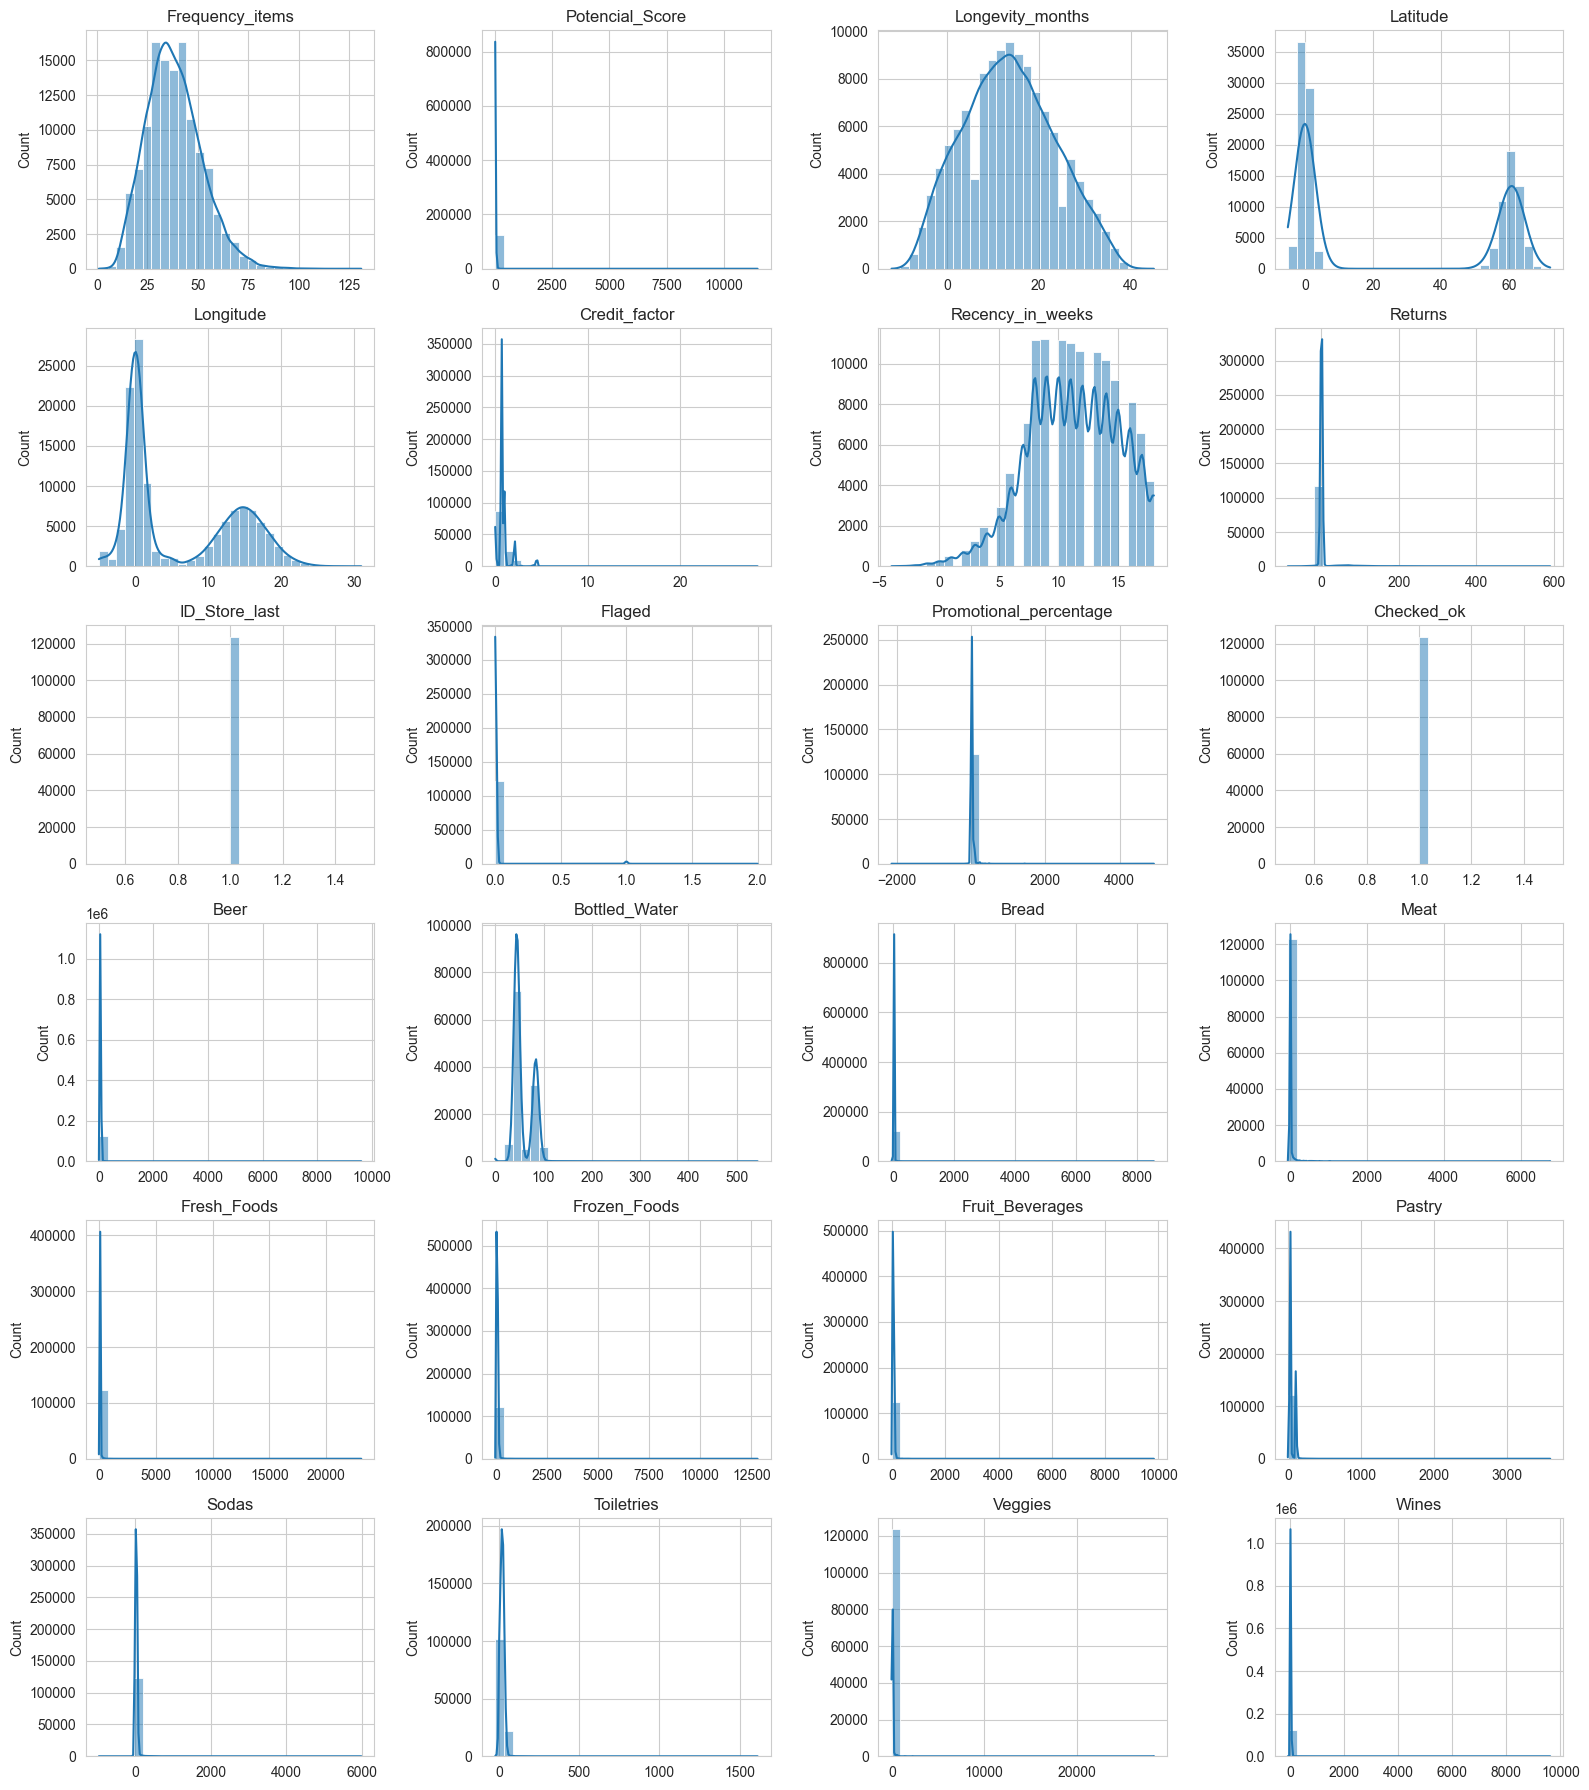

In [7]:
vis.plot_numeric_distributions(data)

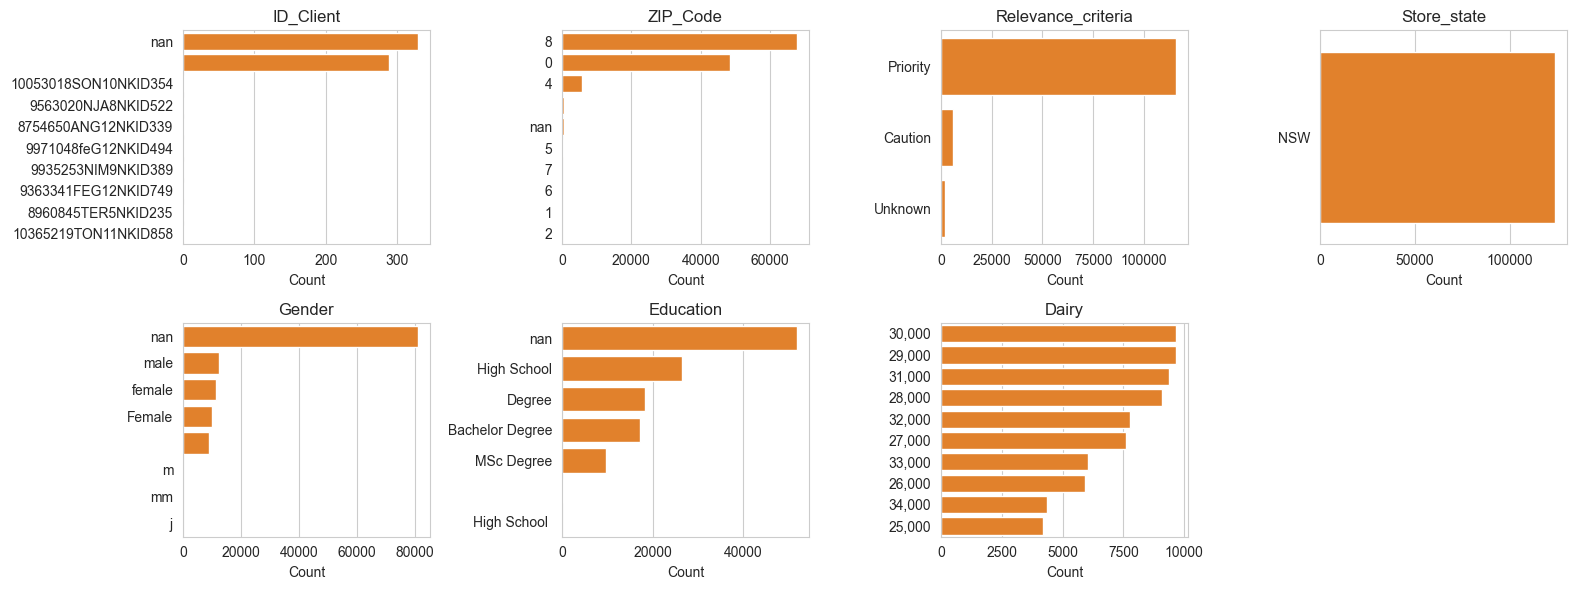

In [8]:
vis.plot_categorical_value_counts(data)

In [9]:
map_obj = vis.plot_world_map(data)
map_obj.save('outputs/world_map.html')
#map_obj

### 2.2. Investigation

In [10]:
# Checking missing values
missing = data.isnull().sum()
pct = missing / len(data) * 100
pd.concat([missing, pct], axis=1, keys=['missing', 'pct']).loc[missing > 0].sort_values('pct', ascending=False)

,missing,pct
Gender,81117,65.584599
Education,51850,41.921687
Frozen_Foods,626,0.506133
ZIP_Code,594,0.480260
ID_Client,329,0.266003


In [11]:
# Checking columns with negative values
preproc.negative_values_report(data)

,neg_count,neg_pct
Latitude,32747,26.476557
Longitude,32673,26.416727
Wines,16870,13.639708
Potencial_Score,16776,13.563707
Veggies,15588,12.603187
Sodas,14472,11.700880
Longevity_months,9827,7.945312
Toiletries,4765,3.852591
Returns,2063,1.667974
Promotional_percentage,1453,1.174777


In [12]:
# Checking distribution of Returns
pct_zero = (data['Returns'] == 0).mean() * 100
print(f"Percentage of values in Returns equal to 0: {pct_zero:.2f}%")

Percentage of values in Returns equal to 0: 93.87%


In [13]:
# Checking distribution of ID_Store_last
data['ID_Store_last'].value_counts(dropna=False)

ID_Store_last
1    123683
Name: count, dtype: int64

In [14]:
# Checking distribution of Flaged
data['Flaged'].value_counts(dropna=False)

Flaged
0    122404
1      1275
2         4
Name: count, dtype: int64

In [15]:
# Checking errors in Potencial_Score
pct_below_0 = (data['Potencial_Score'] < -100).mean() * 100
pct_above_100 = (data['Potencial_Score'] > 100).mean() * 100

print(f"Percentage of Potencial_Score below -100: {pct_below_0:.2f}%")
print(f"Percentage of Potencial_Score above 100: {pct_above_100:.2f}%")

Percentage of Potencial_Score below -100: 0.00%
Percentage of Potencial_Score above 100: 0.68%


In [16]:
# Checking for errors in Promotional_percentage
pct_below_0 = (data['Promotional_percentage'] < 0).mean() * 100
pct_above_100 = (data['Promotional_percentage'] > 100).mean() * 100

print(f"Percentage of rows with Promotional_percentage below 0: {pct_below_0:.2f}%")
print(f"Percentage of rows with Promotional_percentage above 100: {pct_above_100:.2f}%")

Percentage of rows with Promotional_percentage below 0: 1.17%
Percentage of rows with Promotional_percentage above 100: 1.16%


<a id="3"></a> 
## 3. Data Preprocessing

<a id="9"></a> 
### 3.1. Cleanup

In [ ]:
# Dropping unnecessary columns
data_clean = data.drop(columns=['Store_state', 'ID_Store_last','Gender', 'Checked_ok'])

In [ ]:
# Renaming columns for consistency
rename_map = {
    'Recency_in_weeks': 'Recency',
    'Longevity_months': 'Longevity',
    'Flaged': 'Flagged'
}

data_clean = data_clean.rename(columns=rename_map)

In [ ]:
# Converting Dairy to numeric
data_clean['Dairy'] = data_clean['Dairy'].astype(str).str.replace(',', '', regex=False)
data_clean['Dairy'] = pd.to_numeric(data_clean['Dairy'])

<a id="10"></a> 
### 3.2. Missing and negative values

In [20]:
# Removing missing and duplicate values from ID_Client
data_clean = data_clean[data_clean['ID_Client'].notna()].drop_duplicates(subset=['ID_Client'])

In [21]:
# Replacing negative values in Returns, Promotional_percentage, Longevity, and Recency with their absolute values
data_clean['Returns'] = data_clean['Returns'].abs()
data_clean['Promotional_percentage'] = data_clean['Promotional_percentage'].abs()
data_clean['Longevity'] = data_clean['Longevity'].abs()
data_clean['Recency'] = data_clean['Recency'].abs()

In [22]:
# Correcting Potencial_Score and Promotional_percentage values outside the valid ranges
data_clean['Potencial_Score'] = data_clean['Potencial_Score'].clip(upper=100)
data_clean['Promotional_percentage'] = data_clean['Promotional_percentage'].clip(upper=100)

### 3.3. Feature Transformation

In [23]:
# Relevance_criteria: Imputing values where we have ‘Unknown’ and replacing with a binary “Relevance_Priority” column

# 1. map to binary, keep Unknown/nan as missing
mapping = {'Priority': 1, 'Caution': 0, 'Unknown': pd.NA, 'nan': pd.NA}
data_clean['Relevance_Priority'] = data_clean['Relevance_criteria'].replace(mapping)

# 2. numeric predictors
num = data_clean.select_dtypes(include='number').drop(columns=['Relevance_Priority'], errors='ignore')

# 3. separate rows to impute
known_rows = data_clean['Relevance_Priority'].notna()
missing_rows = ~known_rows

# 4. impute
rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
rf.fit(num.loc[known_rows], data_clean.loc[known_rows, 'Relevance_Priority'].astype(int))
data_clean.loc[missing_rows, 'Relevance_Priority'] = rf.predict(num.loc[missing_rows]).astype(int)

# 5. drop original column
data_clean = data_clean.drop(columns=['Relevance_criteria'])
data_clean['Relevance_Priority'] = pd.to_numeric(data_clean['Relevance_Priority'])

In [24]:
# Returns: Creating a binary “Returns_binary” column
data_clean['Returns_binary'] = data_clean['Returns'].apply(lambda x: 0 if x == 0 else 1)
data_clean.drop(columns=['Returns'], inplace=True)

In [25]:
# Flagged: Replacing all values “2” with “1” and replacing datatype with binary
data_clean['Flagged'] = data_clean['Flagged'].replace(2, 1)
data_clean['Flagged'] = data_clean['Flagged'].astype(bool)

In [26]:
# Education: Replacing with a “Education_Years” column, assuming null values equate to 0 years of education
data_clean['Education'] = data_clean['Education'].fillna('High School').astype(str)
data_clean.loc[data_clean['Education'] == '', 'Education'] = 'High School'

education_map = {
    'High School': 12,
    'Degree': 15,
    'Bachelor Degree': 15,
    'MSc Degree': 17
}
data_clean['Education_Years'] = data_clean['Education'].map(education_map).fillna(12).astype(int)
data_clean = data_clean.drop(columns=['Education'])

In [27]:
# Total_profit: Creating a column as the sum of all the spend columns
data_clean['Total_profit'] = data_clean[['Beer', 'Bottled_Water', 'Bread', 'Meat', 'Dairy',
                                                        'Fresh_Foods', 'Frozen_Foods', 'Fruit_Beverages',
                                                        'Pastry', 'Sodas', 'Toiletries', 'Veggies', 'Wines']].sum(axis=1)

<a id="11"></a> 
### 3.4. Scaling

In [ ]:
numeric_cols = data_clean.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    preproc.show_outliers(data_clean[[col]], threshold=3)

Column 'Frequency_items' has 617 outliers.
Column 'Potencial_Score' has 0 outliers.
Column 'Longevity' has 7 outliers.
Column 'Latitude' has 0 outliers.
Column 'Longitude' has 2 outliers.
Column 'Credit_factor' has 3305 outliers.
Column 'Recency' has 0 outliers.
Column 'Promotional_percentage' has 3924 outliers.
Column 'Beer' has 295 outliers.
Column 'Bottled_Water' has 197 outliers.
Column 'Bread' has 273 outliers.
Column 'Meat' has 537 outliers.
Column 'Dairy' has 400 outliers.
Column 'Fresh_Foods' has 165 outliers.
Column 'Frozen_Foods' has 348 outliers.
Column 'Fruit_Beverages' has 302 outliers.
Column 'Pastry' has 341 outliers.
Column 'Sodas' has 503 outliers.
Column 'Toiletries' has 244 outliers.
Column 'Veggies' has 116 outliers.
Column 'Wines' has 103 outliers.
Column 'Relevance_Priority' has 5732 outliers.
Column 'Returns_binary' has 7525 outliers.
Column 'Education_Years' has 0 outliers.
Column 'Total_profit' has 400 outliers.


In [30]:
data_clean, out_report = preproc.clean_outliers(data_clean, threshold=3, count_limit=1000)
print(out_report)

{'dropped_rows': 2599, 'cols_set_to_nan': {'Credit_factor': 3305, 'Promotional_percentage': 3924, 'Relevance_Priority': 5732, 'Returns_binary': 7525}, 'final_shape': (120204, 28)}


In [31]:
# Applying robust scaler to all numeric columns
numeric_cols = data_clean.select_dtypes(include=['int64', 'float64']).columns

scaler = RobustScaler()
data_scaled = data_clean.copy()
data_scaled[numeric_cols] = scaler.fit_transform(data_scaled[numeric_cols])


In [32]:
# Final dataset after preprocessing
display(data_scaled.head())
display(data_scaled.info())

,ID_Client,Frequency_items,Potencial_Score,ZIP_Code,Longevity,Latitude,Longitude,Credit_factor,Recency,Flagged,...,Fruit_Beverages,Pastry,Sodas,Toiletries,Veggies,Wines,Relevance_Priority,Returns_binary,Education_Years,Total_profit
0,10156431SEG17NKID781,0.058824,-0.634897,0,0.714286,-0.016589,-0.188827,0.000000,0.0,False,...,1.069444,-0.294118,-0.179487,0.444444,-0.347826,-0.684211,0.0,0.0,1.000000,1.145724
1,9056576FIA11NKID679,0.764706,-0.632272,0,0.785714,-0.013271,-0.070810,0.000000,-1.0,False,...,-0.111111,-0.058824,-1.102564,-0.944444,0.000000,-0.578947,0.0,0.0,0.000000,1.178959
2,9253304IST6NKID248,0.647059,-0.582392,0,1.357143,-0.009479,0.000000,0.000000,1.0,False,...,-0.041667,0.000000,-0.358974,0.777778,0.347826,-1.368421,0.0,0.0,0.000000,1.157284
3,9661067PER12NKID393,0.529412,-0.648023,0,-0.642857,-0.023224,-0.106215,0.253333,-0.2,False,...,-0.166667,-0.176471,0.000000,0.500000,-0.869565,-0.263158,0.0,0.0,0.000000,1.158167
4,9956825FEG11NKID326,-0.352941,0.205384,8,-0.214286,0.000000,-0.020232,0.000000,-0.6,False,...,-0.013889,0.764706,0.384615,0.000000,0.217391,-0.210526,0.0,0.0,1.666667,1.178558


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120204 entries, 0 to 120203
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID_Client               120204 non-null  object 
 1   Frequency_items         120204 non-null  float64
 2   Potencial_Score         120204 non-null  float64
 3   ZIP_Code                119628 non-null  object 
 4   Longevity               120204 non-null  float64
 5   Latitude                120204 non-null  float64
 6   Longitude               120204 non-null  float64
 7   Credit_factor           120204 non-null  float64
 8   Recency                 120204 non-null  float64
 9   Flagged                 120204 non-null  bool   
 10  Promotional_percentage  120204 non-null  float64
 11  Beer                    120204 non-null  float64
 12  Bottled_Water           120204 non-null  float64
 13  Bread                   120204 non-null  float64
 14  Meat                

None

<a id="4"></a> 
## 4. Clustering

In [ ]:
# Creating two separate dataframes: value-based features and buying-behaviour features.

# define product / buying-behaviour columns
product_cols = [
    'Beer', 'Bottled_Water', 'Bread', 'Meat', 'Dairy',
    'Fresh_Foods', 'Frozen_Foods', 'Fruit_Beverages',
    'Pastry', 'Sodas', 'Toiletries', 'Veggies', 'Wines'
]

# value columns = all columns except ID_Client and product columns
value_cols = [c for c in data_scaled.columns if c != 'ID_Client' and c not in product_cols]


data_value_segments = data_scaled[['ID_Client'] + value_cols].copy()
data_buying_behaviour = data_scaled[['ID_Client'] + product_cols].copy()

### 4.1. Value Segmentation - RFM Analysis

In [ ]:
def rfm_analysis(df, recency_col, frequency_col, monetary_col):
    '''
    Perform RFM analysis on a dataframe.
    
    Inputs:
    - df: Input dataframe
    - recency_col: column name for Recency (eg., 'Recency_in_weeks')
    - frequency_col: column name for Frequency (eg., 'Frequency_items')
    - monetary_col: column name for Monetary (eg., 'Monetary')
    
    Outputs:
    - rfm: dataframe with RFM scores and segments
    '''
    
    rfm = df[[recency_col, frequency_col, monetary_col]].copy()
    
    # Quartile scoring
    rfm['R_Score'] = pd.qcut(rfm[recency_col], 4, labels=[4,3,2,1])  # lower recency = better
    rfm['F_Score'] = pd.qcut(rfm[frequency_col], 4, labels=[1,2,3,4])
    rfm['M_Score'] = pd.qcut(rfm[monetary_col], 4, labels=[1,2,3,4])
    
    # Combine into RFM segment
    rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
    rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)
    
    # Simple segmentation rules
    rfm['Segment'] = np.where(rfm['RFM_Score'] >= 9, 'Champions',
                       np.where(rfm['RFM_Score'] >= 6, 'Loyal',
                       np.where(rfm['RFM_Score'] >= 4, 'Potential',
                                'At Risk')))
    
    return rfm

### 4.2. General Segmentation - KMeans & Agglomerative

### 4.3. Buying Behaviour - 

In [ ]:
# features (drop ID)
X = data_value_segments.drop(columns=['ID_Client']).copy().fillna(0)


In [ ]:
from sklearn.cluster import MiniBatchKMeans # More efficient for large datasets

ks = range(2, 7)
inertias, silhs = [], []
for k in ks:
    km = MiniBatchKMeans(n_clusters=k, random_state=0, batch_size=1000, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhs.append(float(silhouette_score(X, labels)) if len(np.unique(labels)) > 1 else np.nan)

ValueError: x and y must have same first dimension, but have shapes (19,) and (5,)

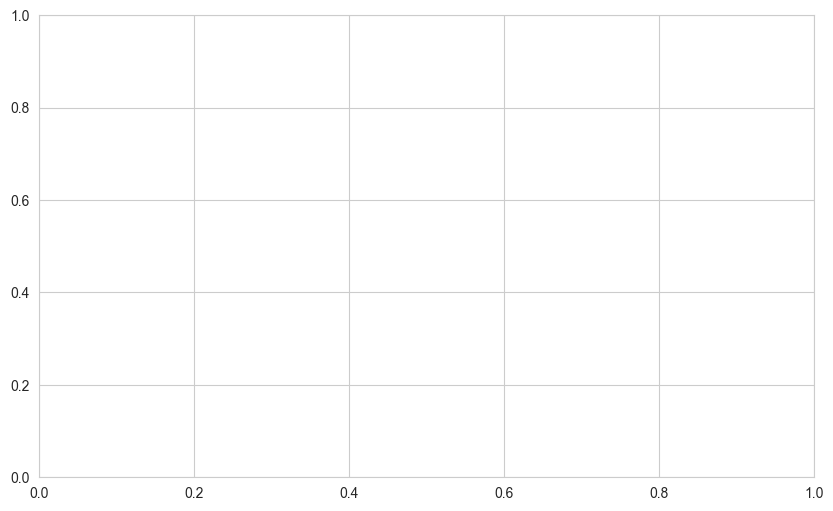

In [ ]:
cluster.plot_elbow_graph(inertias)

In [ ]:
# Kmeans clustering
km = KMeans(n_clusters=4, random_state=0, n_init=10)
data_value_segments['Kmeans_cluster'] = km.fit_predict(X)

print('Chosen k:', 4)
print(data_value_segments['Kmeans_cluster'].value_counts())

# attach cluster labels to scaled dataframe for later analysis
data_preprocessed_labels = data_preprocessed.merge(data_value_segments[['ID_Client', 'Kmeans_cluster']], on='ID_Client', how='left')

Chosen k: 4
Kmeans_cluster
0    117761
2      3727
1      1043
3       272
Name: count, dtype: int64


Chosen k: 4
Kmeans_cluster
0    117714
3      3762
2      1055
1       272
Name: count, dtype: int64


In [ ]:
def plot_cluster_description(df):
    df = df.select_dtypes(include=[np.number])

    # Plotting cluster description using only the modelling variables
    cluster_means = df.groupby('cluster_kmeans').mean()
    overall_mean = df.mean()

    overall_mean_df = overall_mean.to_frame().T
    overall_mean_df.index = ['Overall Mean']
    plt.figure(figsize=(14, 8))

    # Plot each variable's mean for each cluster using clustered bar plots
    ax = cluster_means.T.plot(kind='bar', width=0.4, position=1.5, ax=None, figsize=(14, 8))

    # Plot the overall mean using a line plot on the same axes
    overall_mean_df.T.plot(kind='line', marker='o', linestyle='--', color='black', linewidth=2, ax=ax, label='Overall Mean')

    plt.title('Mean of Each Variable by Cluster with Overall Mean')
    plt.xlabel('Variables')
    plt.ylabel('Mean Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_cluster_sizes(df, name_column):
    df.groupby([name_column]).size().plot(kind='bar')
    plt.show()

In [ ]:
eps_range = np.arange(1, 2.5, 0.1)
min_samples_range = range(5, 13)

# Function to calculate and print cluster sizes and noise points
def print_cluster_info(labels):
    unique_labels, counts = np.unique(labels, return_counts=True)
    cluster_info = dict(zip(unique_labels, counts))

    noise_points = cluster_info.get(-1, 0)
    clusters = {k: v for k, v in cluster_info.items() if k != -1}

    return clusters, noise_points

# Grid search over the parameter ranges
for min_samples in min_samples_range:
    for eps_val in eps_range:
        model = DBSCAN(eps=eps_val, min_samples=min_samples)
        labels = model.fit_predict(sample_purchase)

        clusters, noise_points = print_cluster_info(labels)

        if noise_points <= 500:
            print(f'eps: {round(eps_val,2)}, min_samples: {min_samples}')
            print(f'Cluster sizes: {clusters}')
            print(f'Number of noise points: {noise_points}')
            print('-' * 40)

### 4.3. Buying Behaviour Segmentation

In [ ]:
def buying_behavior_segmentation(df, category_cols, n_clusters=5, random_state=42):
    '''
    Perform buying behavior segmentation using product category spend.
    
    Inputs:
    - df: input dataframe
    - category_cols: list of product category columns
    - n_clusters: number of clusters for KMeans
    - random_state: random seed for reproducibility
    
    Outputs:
    - df: original dataframe with cluster labels
    - cluster_profiles: mean normalized spend per category for each cluster
    '''
    
    # Normalize spend per customer (percentage of total spend)
    behavior = df[category_cols].div(df[category_cols].sum(axis=1), axis=0).fillna(0)
    
    # Standardize for clustering
    scaler = StandardScaler()
    behavior_scaled = scaler.fit_transform(behavior)
    
    # KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    df['BehaviorCluster'] = kmeans.fit_predict(behavior_scaled)
    
    # Validation
    sil_score = silhouette_score(behavior_scaled, df['BehaviorCluster'])
    print(f"Silhouette Score: {sil_score:.3f}")
    
    # Cluster profiling
    cluster_profiles = behavior.groupby(df['BehaviorCluster']).mean()
    
    return df, cluster_profiles

In [ ]:
categories = ['Beer','Meat','Dairy','Wines','Fresh_Foods','Frozen_Foods',
              'Pastry','Sodas','Toiletries','Veggies','Bread','Fruit_Beverages','Bottled_Water']

df, profiles = buying_behavior_segmentation(df, categories, n_clusters=5)

print(profiles)

# Visualize cluster profiles
plt.figure(figsize=(12,6))
sns.heatmap(profiles, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Buying Behavior Cluster Profiles (Normalized Spend)")
plt.show()

In [ ]:
def plot_radar_per_cluster(cluster_profiles, categories):
    '''
    Plot one radar chart per cluster profile.
    
    Parameters:
    cluster_profiles: output of buying_behavior_segmentation
    categories: list of product category names
    '''
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the loop
    
    for cluster in cluster_profiles.index:
        values = cluster_profiles.loc[cluster].tolist()
        values += values[:1]  # close the loop
        
        fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
        ax.plot(angles, values, linewidth=2, label=f"Cluster {cluster}")
        ax.fill(angles, values, alpha=0.25)
        
        # Add category labels
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories)
        
        # Add y-labels
        ax.set_yticks([0.1,0.2,0.3,0.4,0.5])
        ax.set_yticklabels(["10%","20%","30%","40%","50%"])
        ax.set_ylim(0,0.6)
        
        plt.title(f"Buying Behavior Profile - Cluster {cluster}", size=14)
        plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
        plt.show()

In [ ]:
categories = ['Beer','Meat','Dairy','Wines','Fresh_Foods','Frozen_Foods',
              'Pastry','Sodas','Toiletries','Veggies','Bread','Fruit_Beverages','Bottled_Water']

# profiles = output from buying_behavior_segmentation
plot_radar_chart(profiles, categories)